In [1]:
import sys
import os
os.chdir("/home/karlandersson/Programming/MasterThesisProject")
print(os.getcwd())

/home/karlandersson/Programming/MasterThesisProject


In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np

from utils.heatpipe_utils import generate_cfgs_seq, plot_heatpipe_solutions
from utils.solver import Solver

from coupled.heatpipe import Heatpipe

import utils.sodium_properties as s_props

Mesh warning: N_Z changed from 50 to 54
Mesh warning: Neutronics N_Z changed from 50 to 30
Mesh warning: N_R changed from 15 to 65


In [3]:
with open("data/vapour_data.json", "r") as f:
    data_guoju = json.load(f) 
    data = data_guoju["data_guoju_560"]
    # data["material"]["h_cond"] = 62.7
    # data["material"]["h_cond"] = 59.6

In [4]:
ncfgs = 1
Qs = [data["bc"]["Q"] for i in range(ncfgs)]
Ns = [[30, 100] for i in range(len(Qs))]
cfgs = generate_cfgs_seq(data, Ns, Qs)

heatpipe = Heatpipe(cfgs[0])
heatpipe.solid.use_self_properties = False
heatpipe.solid.variable_k = True
solver = Solver([heatpipe])
solver.fsolve()

In [5]:
T_solid, u, mach, T_vap = solver.solutions[0]
Z = heatpipe.solid.Z
cfg = heatpipe.cfg

print(T_solid.shape, mach.shape, T_vap.shape, Z.shape)
print(np.max(mach))
print(heatpipe.cfg.geometry.r_vapour)

T_test = np.array([797.0, 805.0, 818.0])

rho_emp = s_props.calculate_Na_rho_v(T_test)
rho_hu = s_props.calculate_rho_cc(T_test)  # assuming this uses P_C=1300, T_C=818, h_fg=4.182e6

print("T:", T_test)
print("rho empirical:", rho_emp)
print("rho Hu/CC:", rho_hu)
print("ratio empirical / Hu:", rho_emp / rho_hu)

(100, 30) (100,) (100,) (100,)
0.3578061547138904
0.007
T: [797. 805. 818.]
rho empirical: [0.00325283 0.00375724 0.00471947]
rho Hu/CC: [0.00310737 0.00355359 0.00439381]
ratio empirical / Hu: [1.0468107  1.05730963 1.07411712]


In [6]:
T_face = 0.5 * (T_vap[:-1] + T_vap[1:])
rho_face = heatpipe.vapour.calculate_rho(T_face)

A_v = np.pi * cfg.geometry.r_vapour**2
mdot = rho_face * u * A_v

z_face = 0.5 * (Z[:-1] + Z[1:])

print("max mdot1:", np.max(mdot))
print("expected Q/h_fg:", 560.0 / 4.182e6)
print("ratio:", np.max(mdot) / (560.0 / 4.182e6))

print("max u:", np.max(u))
print("z max u:", z_face[np.argmax(u)])

max mdot1: 0.00013346423061530636
expected Q/h_fg: 0.00013390722142515542
ratio: 0.9966918079164486
max u: 242.48416569847072
z max u: 0.15000000000000002


In [7]:
R_Na = 361.7
gamma = 5.0 / 3.0

c_face = np.sqrt(gamma * R_Na * T_face)
mach_face = u / c_face

print("max face Mach:", np.max(mach_face))
print("z max face Mach:", z_face[np.argmax(mach_face)])
print("max postprocessed nodal Mach:", np.max(mach))

max face Mach: 0.34869234006845534
z max face Mach: 0.15000000000000002
max postprocessed nodal Mach: 0.3578061547138904


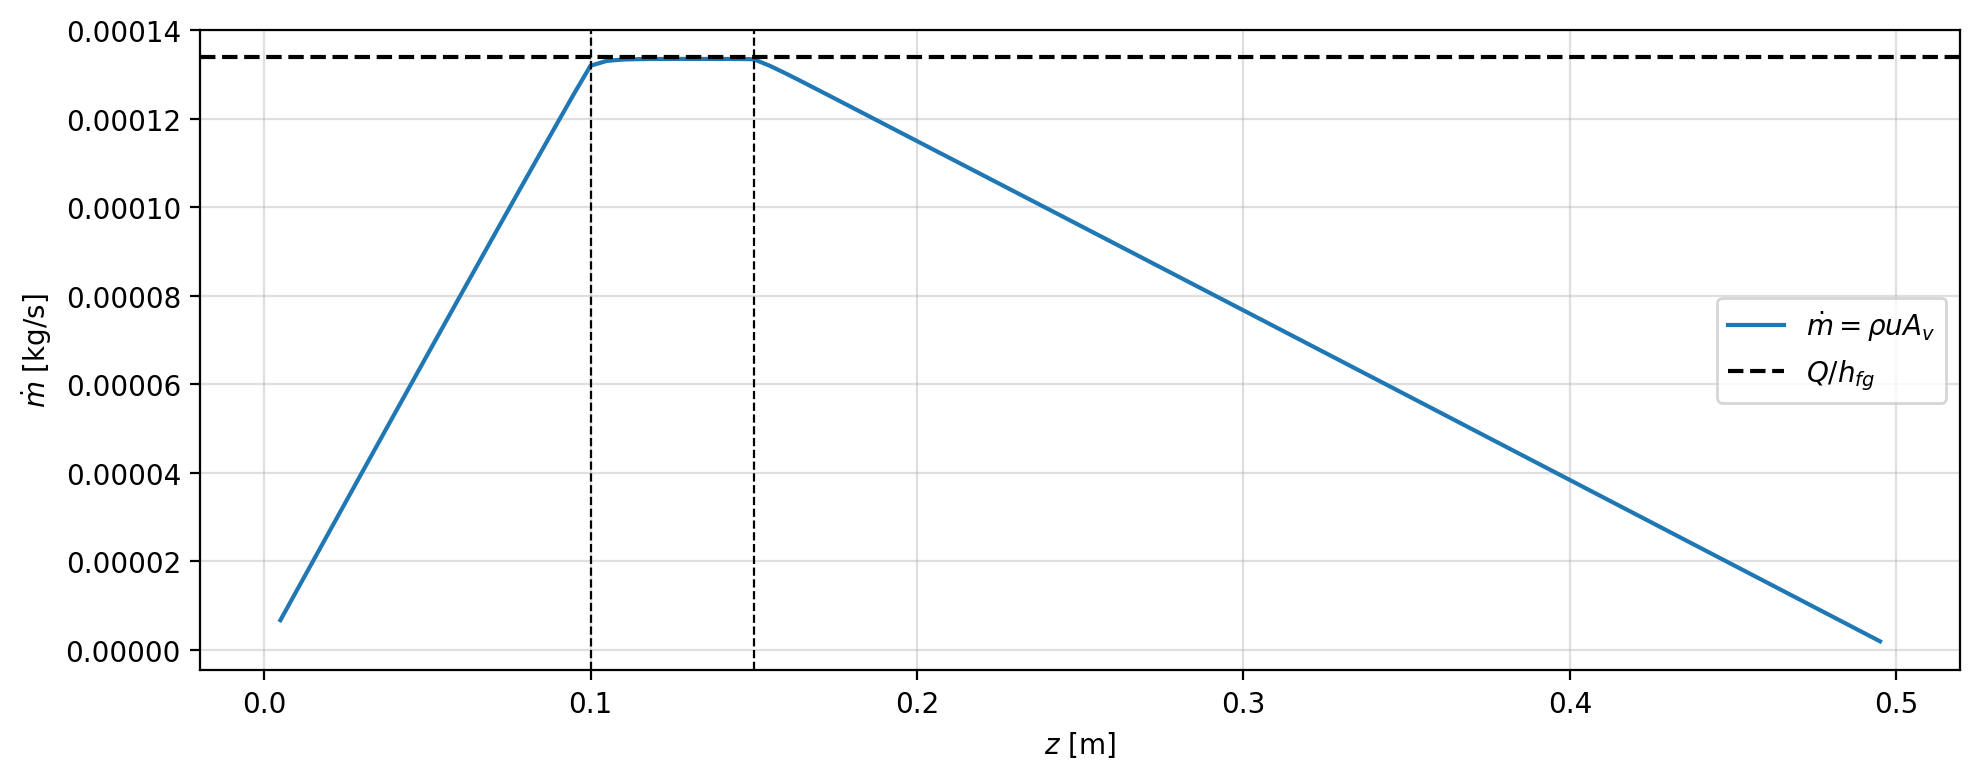

In [8]:
fig, ax = plt.subplots(figsize=(10, 4), dpi=200)

ax.plot(z_face, mdot, label=r"$\dot m = \rho u A_v$")
ax.axhline(data["bc"]["Q"] / 4.182e6, color="k", linestyle="--", label=r"$Q/h_{fg}$")

ax.axvline(cfg.geometry.l_evap, color="k", linestyle="--", linewidth=0.8)
ax.axvline(cfg.geometry.l_evap + cfg.geometry.l_adiabatic, color="k", linestyle="--", linewidth=0.8)

ax.set_xlabel(r"$z$ [m]")
ax.set_ylabel(r"$\dot m$ [kg/s]")
ax.grid(alpha=0.4)
ax.legend()

fig.tight_layout()
plt.show()

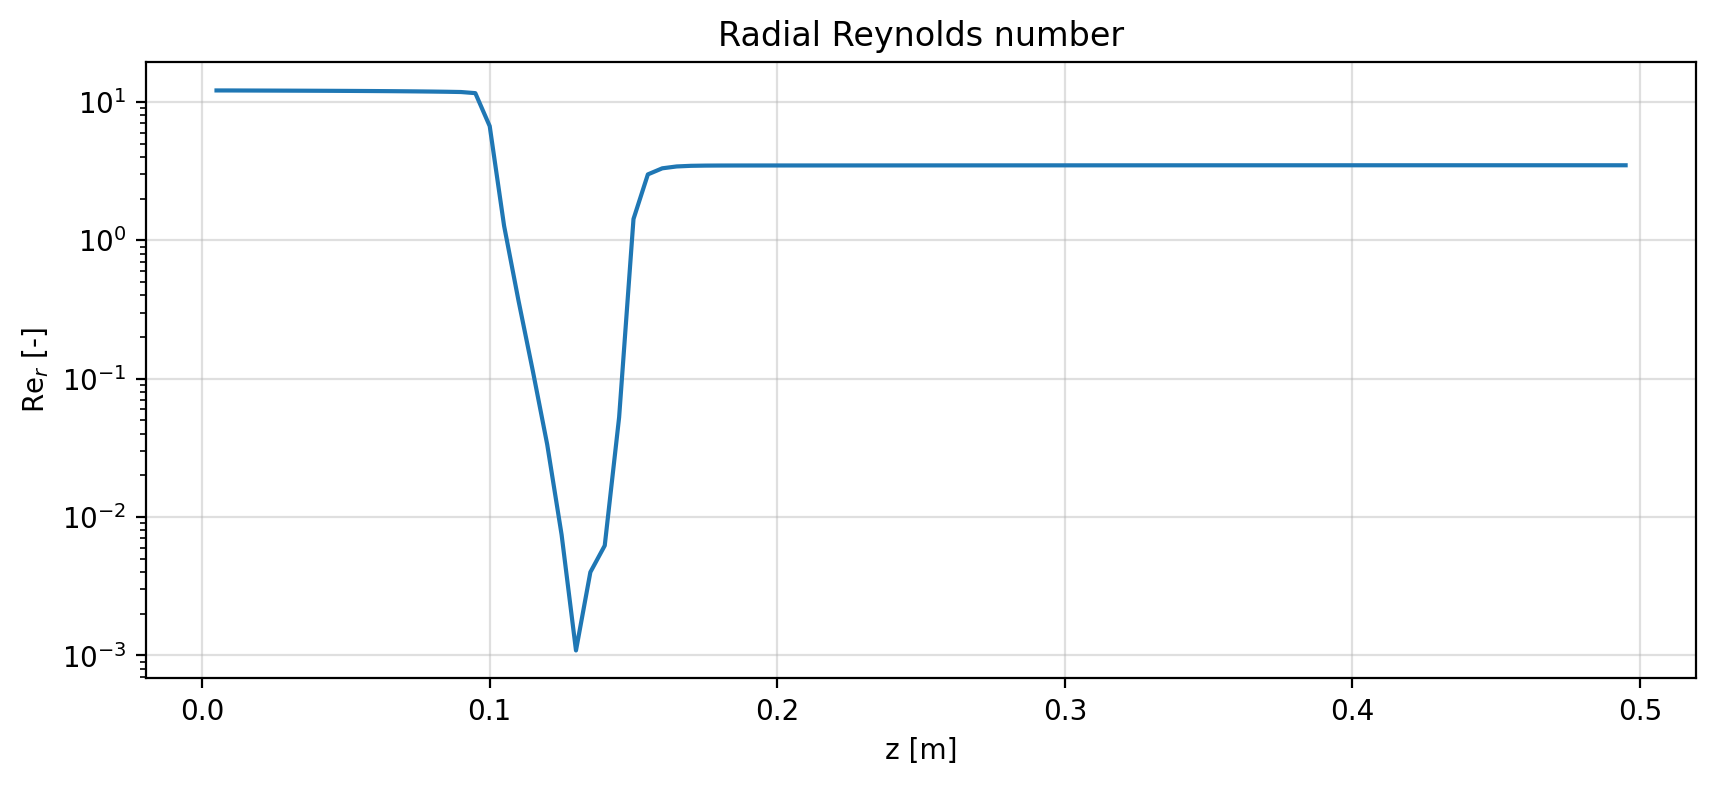

In [9]:
dmdotdz = np.gradient(mdot, z_face)
Re_r = 1/(2*np.pi*s_props.calculate_Na_viscosity_v(T_face)) * dmdotdz

plt.figure(figsize=(10,4), dpi=200)

plt.plot(z_face, np.abs(Re_r))

plt.grid(alpha=0.4)
plt.yscale("log")

plt.xlabel("z [m]")
plt.ylabel(r"Re$_r$ [-]")
plt.title("Radial Reynolds number")

plt.show()

In [10]:
%config InlineBackend.figure_format = "retina"

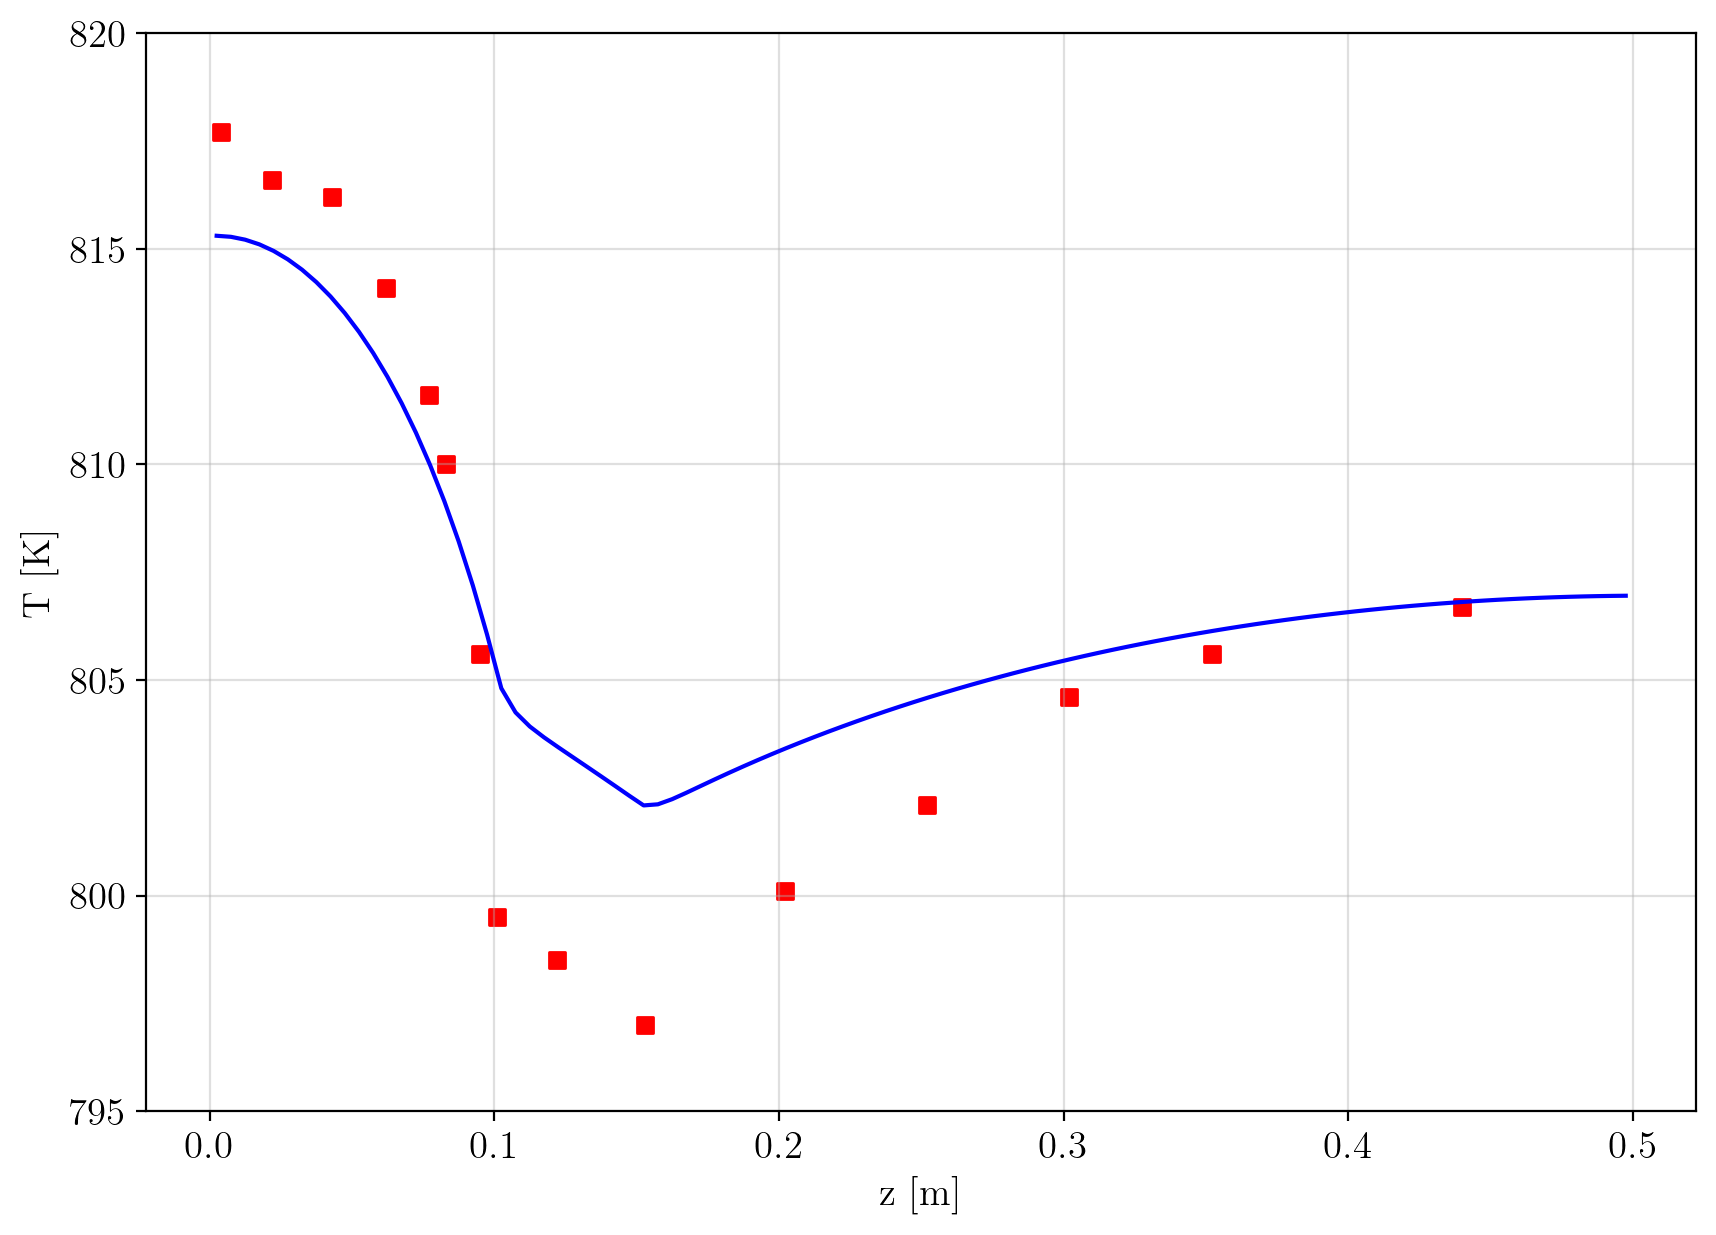

In [11]:
z_ivanovski = np.array([0.004, 0.022, 0.043, 0.062, 0.077, 0.083, 0.095, 0.101, 0.122, 0.153, 0.202, 0.252, 0.302, 0.352, 0.440])
T_ivanovski = np.array([817.7, 816.6, 816.2, 814.1, 811.6, 810.0, 805.6, 799.5, 798.5, 797.0, 800.1, 802.1, 804.6, 805.6, 806.7])

# z_ivanovski = np.array([0.0204, 0.0444, 0.0639, 0.0825, 0.1027, 0.1515, 0.2015, 0.2305, 0.2814, 0.3447, 0.3843, 0.4840, 0.5338, 0.6008])
# T_ivanovski = np.array([855.61, 854.73, 852.73, 850.19, 844.70, 840.20, 843.17, 844.19, 844.67, 845.27, 845.65, 845.95, 845.93, 846.06])

plt.rcParams["font.family"] = "Computer Modern"
plt.rcParams["font.size"] = 14
plt.rcParams["text.usetex"] = True

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111)

ax.scatter(z_ivanovski, T_ivanovski, label="Ivanovski", marker="s", color="red")
ax.plot(Z, T_vap, label="Model", color="blue")
ax.grid(alpha=0.4)

ax.set_xlabel("z [m]", fontsize=14)
ax.set_ylabel("T [K]", fontsize=14)

ax.set_ylim((795, 820))
# ax.set_ylim((835, 860))

plt.show()

In [12]:
T_int = T_solid[:, 0]
q_bis_surface = heatpipe.cfg.material.h_vap * (T_int - T_vap)

evap = slice(0, heatpipe.cfg.mesh.N_evap)
adiab = slice(
    heatpipe.cfg.mesh.N_evap,
    heatpipe.cfg.mesh.N_evap + heatpipe.cfg.mesh.N_adiabatic,
)
cond = slice(
    heatpipe.cfg.mesh.N_evap + heatpipe.cfg.mesh.N_adiabatic,
    heatpipe.cfg.mesh.N_Z,
)

dx = heatpipe.vapour.dx
r_vap = heatpipe.cfg.geometry.r_vapour
A_inner = 2.0 * np.pi * r_vap * dx

Q_vap_cells = q_bis_surface * A_inner

print("Q vap evap:", np.sum(Q_vap_cells[evap]))
print("Q vap adiab:", np.sum(Q_vap_cells[adiab]))
print("Q vap cond:", np.sum(Q_vap_cells[cond]))
print("Q vap net:", np.sum(Q_vap_cells))
print("max |T_int - T_vap| adiab:", np.max(np.abs(T_int[adiab] - T_vap[adiab])))

Q vap evap: 557.6586254256215
Q vap adiab: 1.815640016694503
Q vap cond: -559.474265442316
Q vap net: 5.684341886080802e-14
max |T_int - T_vap| adiab: 0.01124934481811124


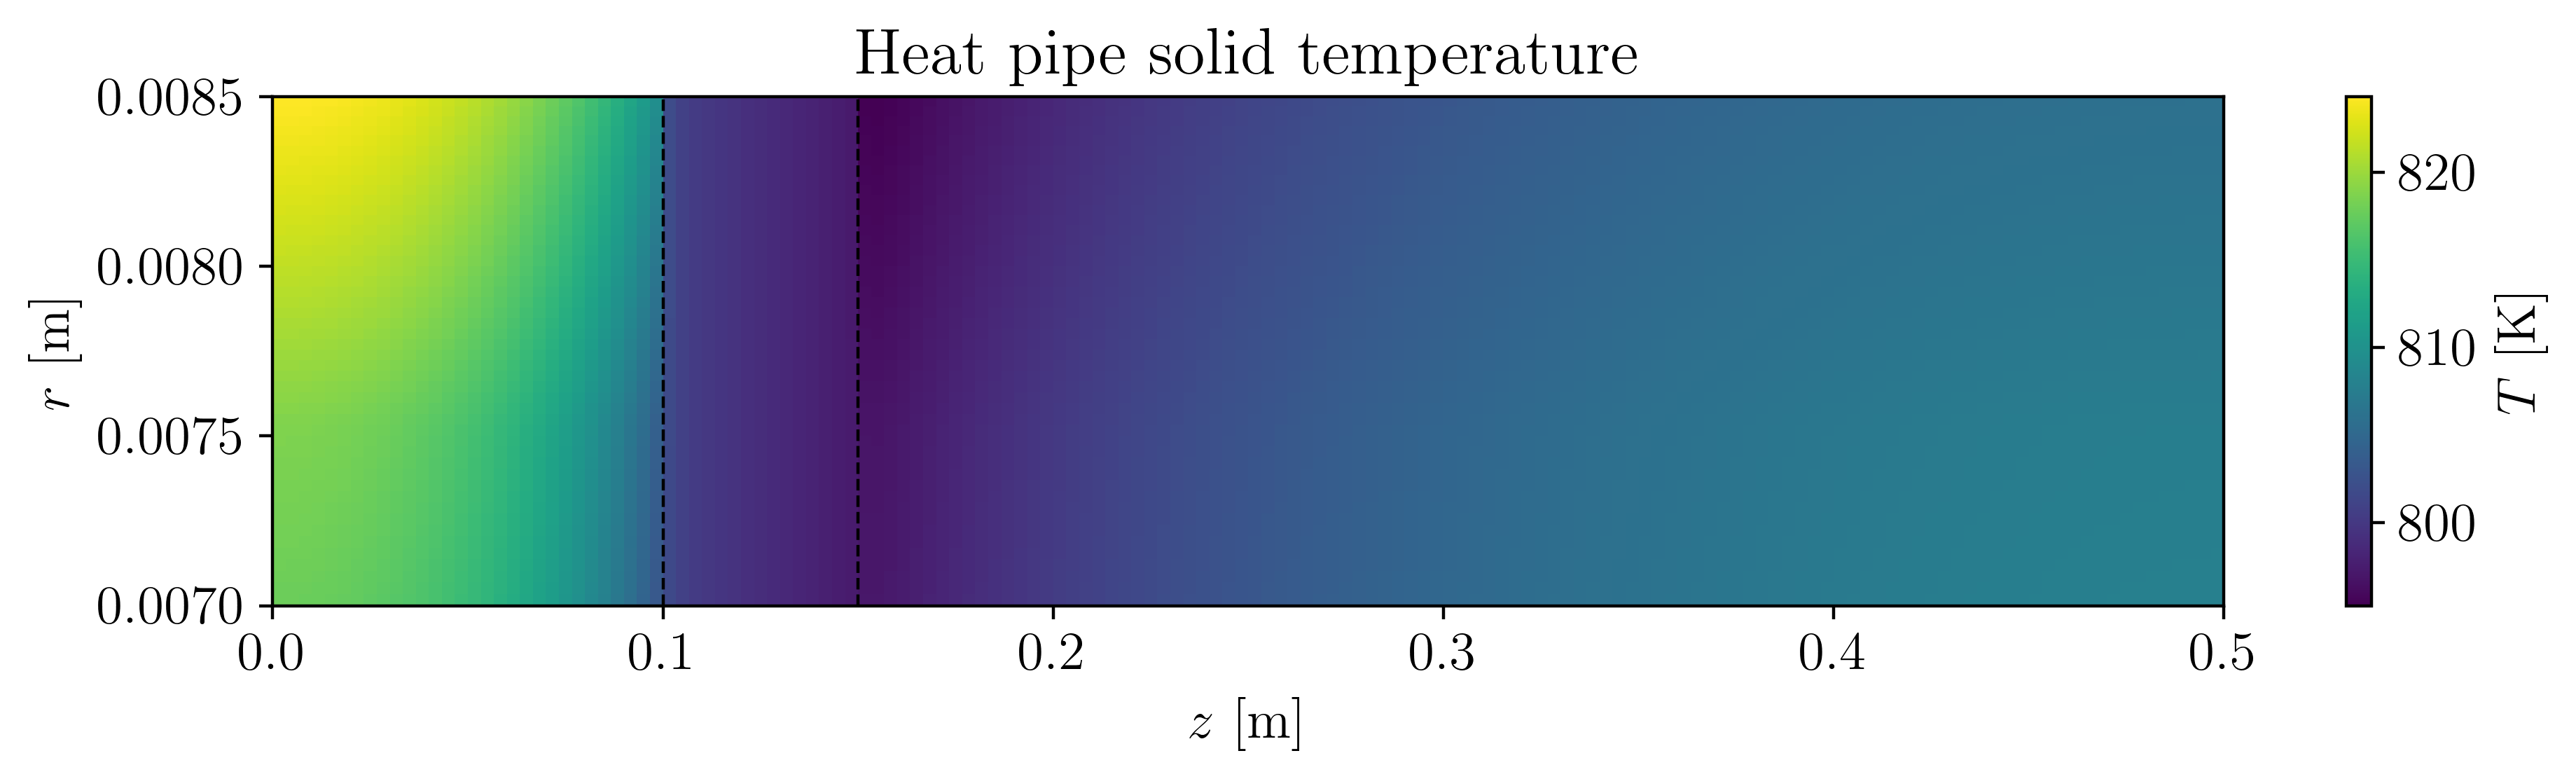

In [13]:
def centers_to_edges(x, first_edge=None, last_edge=None):
    edges = np.empty(len(x) + 1)
    edges[1:-1] = 0.5 * (x[:-1] + x[1:])

    if first_edge is None:
        edges[0] = x[0] - 0.5 * (x[1] - x[0])
    else:
        edges[0] = first_edge

    if last_edge is None:
        edges[-1] = x[-1] + 0.5 * (x[-1] - x[-2])
    else:
        edges[-1] = last_edge

    return edges


R = heatpipe.solid.R

cfg = heatpipe.cfg

z_edges = centers_to_edges(
    Z,
    first_edge=0.0,
    last_edge=cfg.geometry.l_evap + cfg.geometry.l_adiabatic + cfg.geometry.l_cond,
)

r_edges = centers_to_edges(
    R,
    first_edge=cfg.geometry.r_vapour,
    last_edge=cfg.geometry.r_outer,
)

fig, ax = plt.subplots(figsize=(10, 3), dpi=200)

c = ax.pcolormesh(
    z_edges,
    r_edges,
    T_solid.T,
    shading="flat",
)

fig.colorbar(c, ax=ax, label=r"$T$ [K]")

z_evap_end = cfg.geometry.l_evap
z_adiab_end = cfg.geometry.l_evap + cfg.geometry.l_adiabatic

ax.axvline(z_evap_end, color="k", linestyle="--", linewidth=0.8)
ax.axvline(z_adiab_end, color="k", linestyle="--", linewidth=0.8)

ax.set_xlabel(r"$z$ [m]")
ax.set_ylabel(r"$r$ [m]")
ax.set_title("Heat pipe solid temperature")

fig.tight_layout()
plt.show()

In [14]:
def heatpipe_diagnostics(heatpipe, T_solid, T_vap, label="case"):
    cfg = heatpipe.cfg

    evap = slice(0, cfg.mesh.N_evap)
    adiab = slice(cfg.mesh.N_evap, cfg.mesh.N_evap + cfg.mesh.N_adiabatic)
    cond = slice(cfg.mesh.N_evap + cfg.mesh.N_adiabatic, cfg.mesh.N_Z)

    T_int = T_solid[:, 0]
    T_outer = T_solid[:, -1]

    dx = heatpipe.vapour.dx
    r_vap = cfg.geometry.r_vapour
    h_vap = cfg.material.h_vap

    q_bis = np.zeros_like(T_vap)

    q_bis[evap] = h_vap * (T_int[evap] - T_vap[evap])
    q_bis[cond] = h_vap * (T_int[cond] - T_vap[cond])

    A_inner = 2.0 * np.pi * r_vap * dx
    Q_vap_cells = q_bis * A_inner

    print(f"\n--- {label} ---")
    print("T_vap min/max:", np.min(T_vap), np.max(T_vap))
    print("T_int evap mean:", np.mean(T_int[evap]))
    print("T_int adiab mean:", np.mean(T_int[adiab]))
    print("T_int cond mean:", np.mean(T_int[cond]))
    print("T_outer evap mean:", np.mean(T_outer[evap]))
    print("T_outer adiab mean:", np.mean(T_outer[adiab]))
    print("T_outer cond mean:", np.mean(T_outer[cond]))

    print("\nHeat transfer to vapour")
    print("Q evap:", np.sum(Q_vap_cells[evap]))
    print("Q adiab:", np.sum(Q_vap_cells[adiab]))
    print("Q cond:", np.sum(Q_vap_cells[cond]))
    print("Q net:", np.sum(Q_vap_cells))

    return {
        "T_int": T_int,
        "T_outer": T_outer,
        "q_bis": q_bis,
        "Q_vap_cells": Q_vap_cells,
    }

diag = heatpipe_diagnostics(
    heatpipe,
    T_solid,
    T_vap,
    label="radial adiabatic conduction disabled",
)


--- radial adiabatic conduction disabled ---
T_vap min/max: 797.1064858326424 817.6392432628948
T_int evap mean: 813.394692835462
T_int adiab mean: 799.1042464304925
T_int cond mean: 804.5285043877478
T_outer evap mean: 819.9231018581038
T_outer adiab mean: 799.1220805225322
T_outer cond mean: 802.6606969388976

Heat transfer to vapour
Q evap: 557.6586254256215
Q adiab: 0.0
Q cond: -559.474265442316
Q net: -1.815640016694374


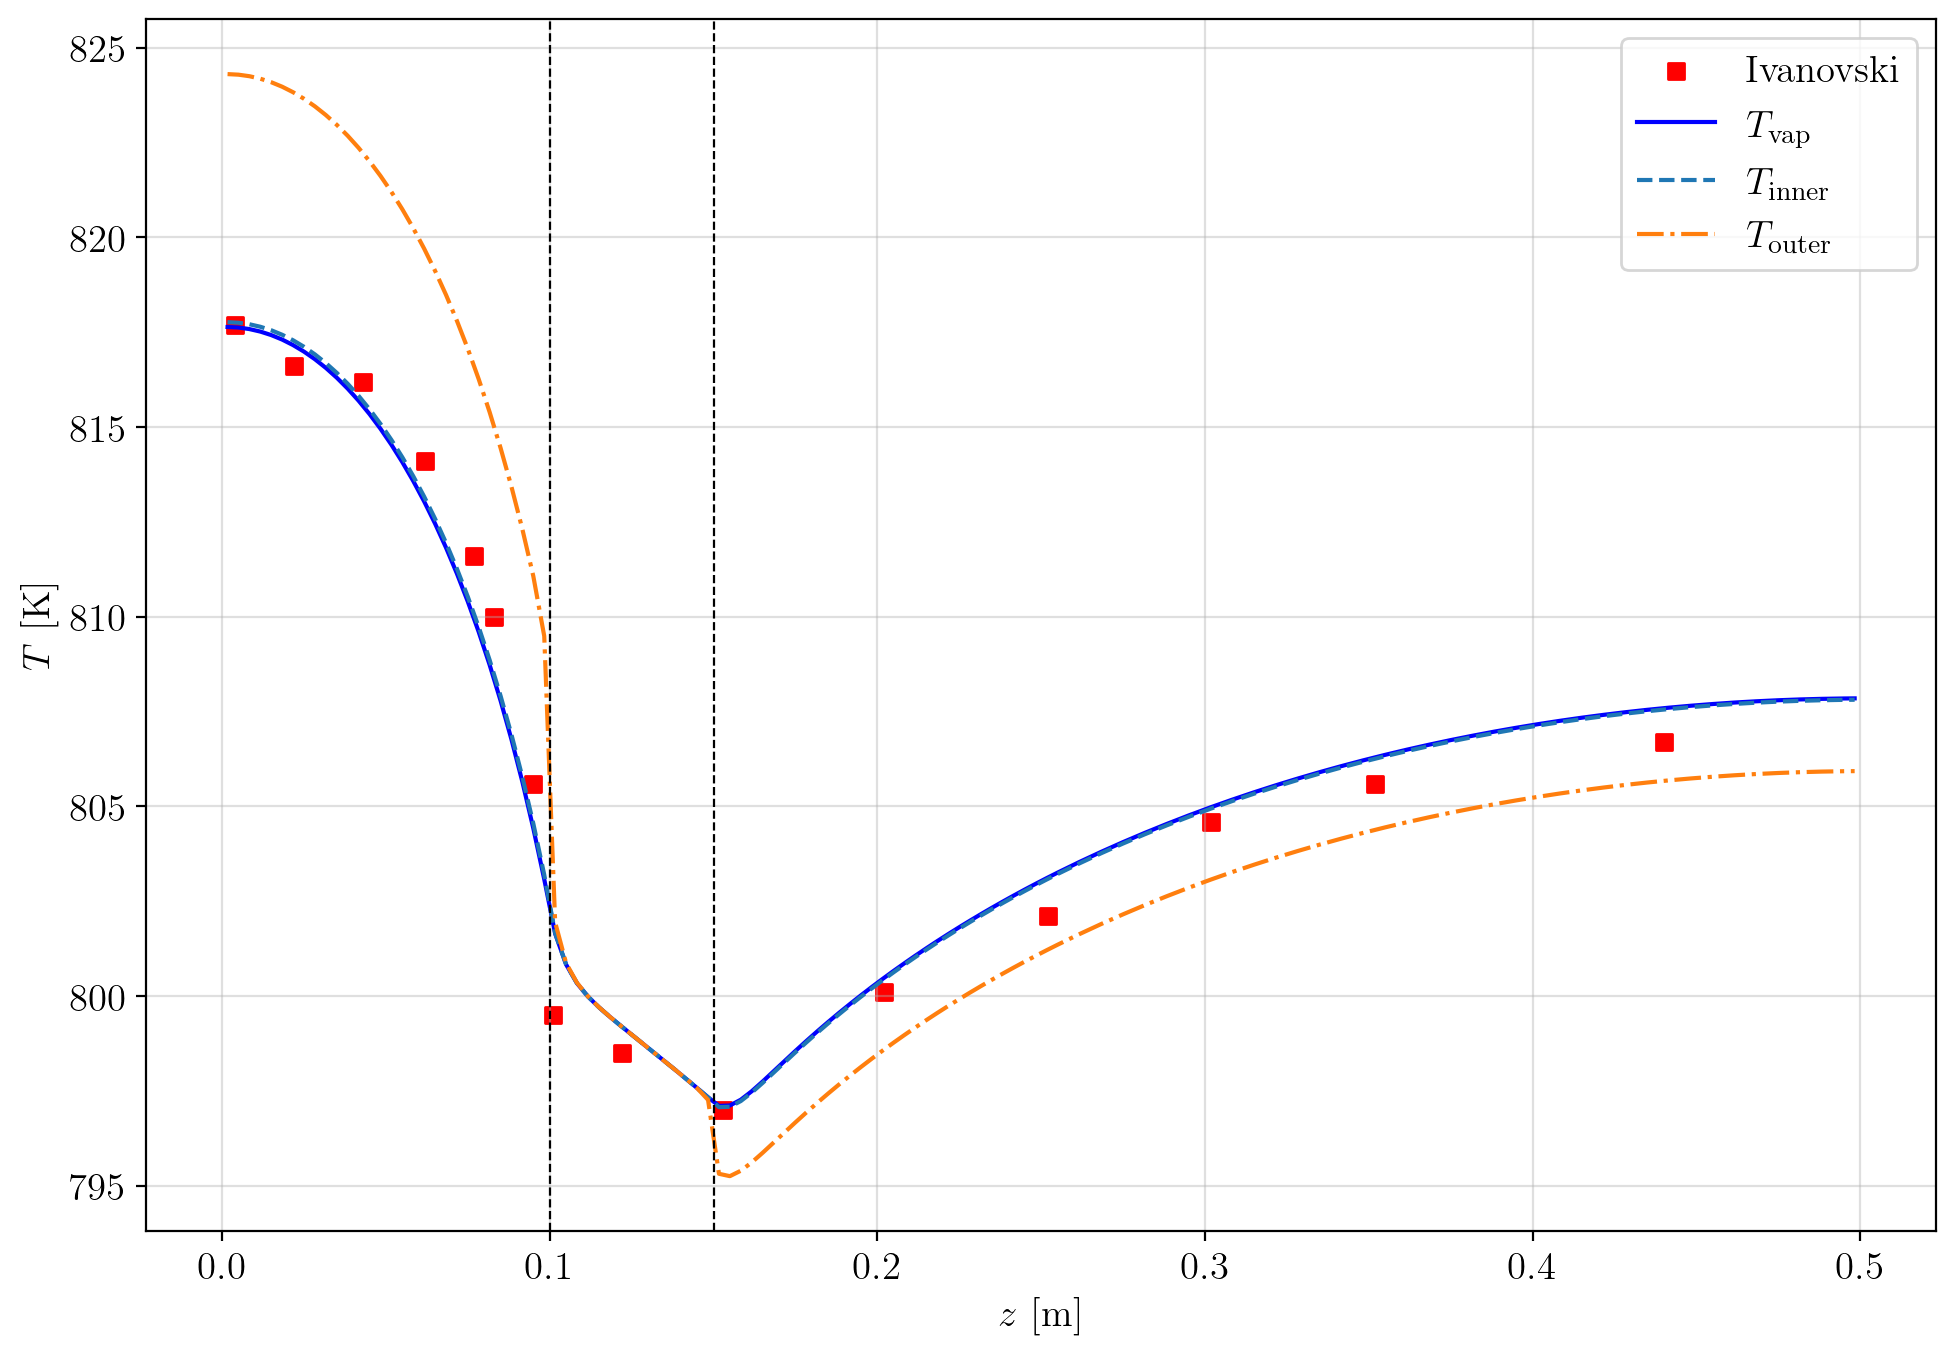

In [15]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(z_ivanovski, T_ivanovski, label="Ivanovski", marker="s", color="red")

ax.plot(Z, T_vap, label=r"$T_\mathrm{vap}$", color="blue")
ax.plot(Z, T_solid[:, 0], label=r"$T_\mathrm{inner}$", linestyle="--")
ax.plot(Z, T_solid[:, -1], label=r"$T_\mathrm{outer}$", linestyle="-.")

ax.axvline(heatpipe.cfg.geometry.l_evap, color="k", linestyle="--", linewidth=0.8)
ax.axvline(
    heatpipe.cfg.geometry.l_evap + heatpipe.cfg.geometry.l_adiabatic,
    color="k",
    linestyle="--",
    linewidth=0.8,
)

ax.grid(alpha=0.4)
ax.set_xlabel(r"$z$ [m]")
ax.set_ylabel(r"$T$ [K]")
# ax.set_ylim((795, 825))
ax.legend()

fig.tight_layout()
plt.show()

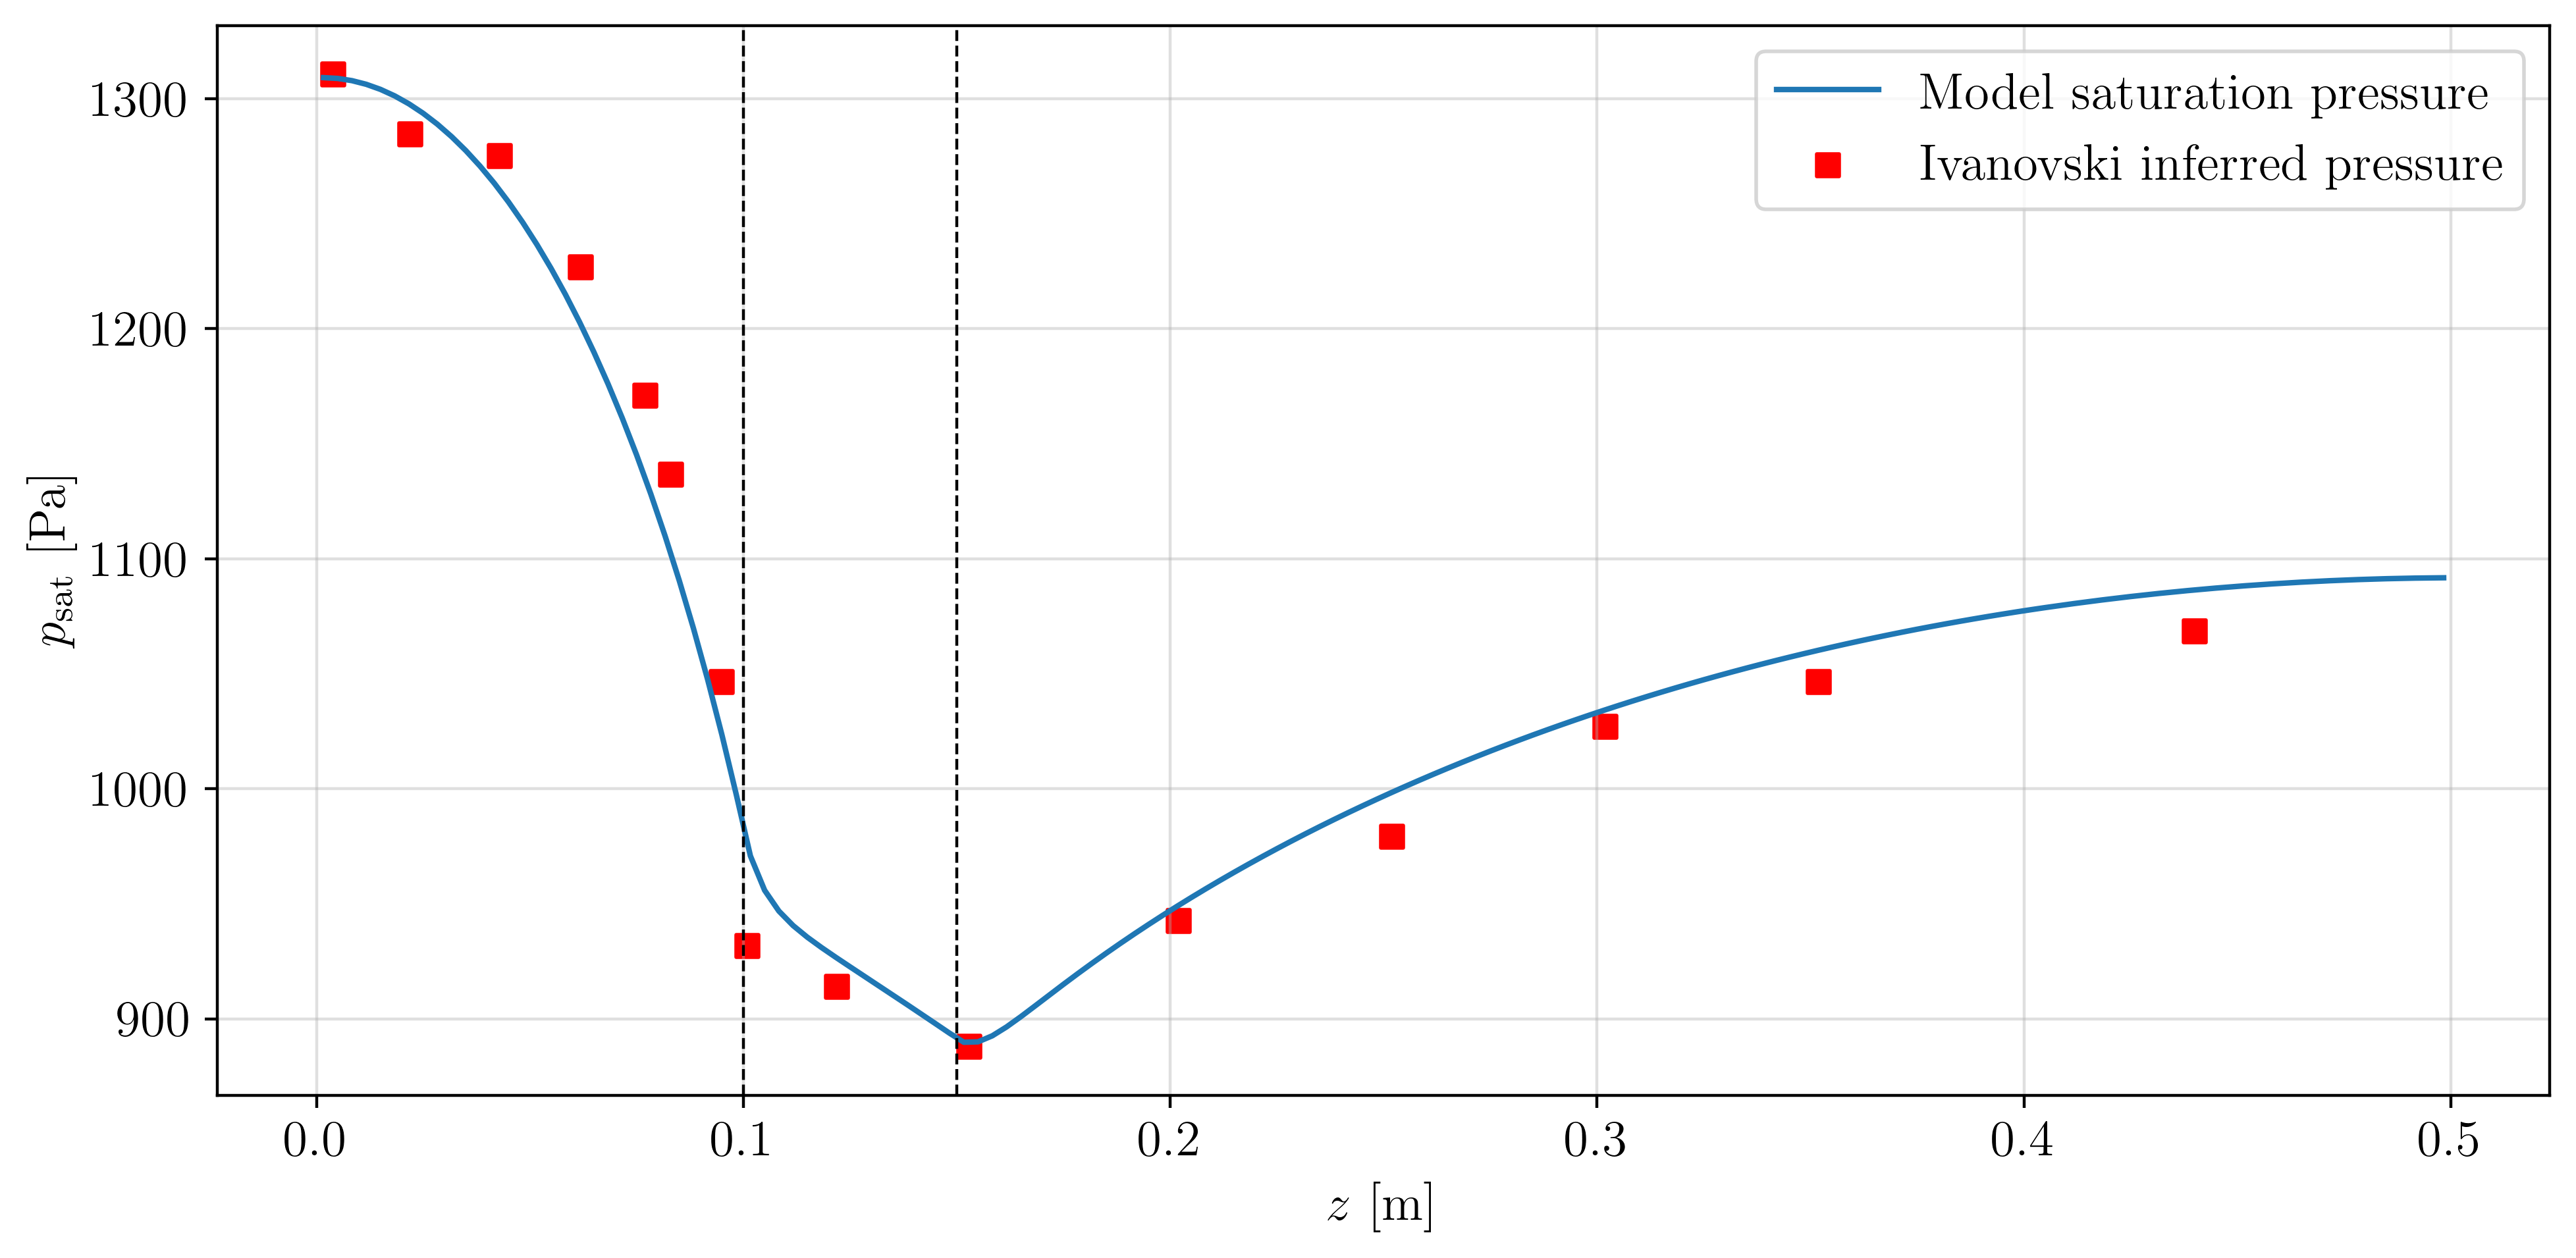

In [16]:
p_vap = s_props.calculate_Na_pressure_v(T_vap)
p_exp = s_props.calculate_Na_pressure_v(T_ivanovski)

fig, ax = plt.subplots(figsize=(10, 5), dpi=200)

ax.plot(Z, p_vap, label="Model saturation pressure")
ax.scatter(z_ivanovski, p_exp, label="Ivanovski inferred pressure", marker="s", color="red")

ax.axvline(heatpipe.cfg.geometry.l_evap, color="k", linestyle="--", linewidth=0.8)
ax.axvline(
    heatpipe.cfg.geometry.l_evap + heatpipe.cfg.geometry.l_adiabatic,
    color="k",
    linestyle="--",
    linewidth=0.8,
)

ax.set_xlabel(r"$z$ [m]")
ax.set_ylabel(r"$p_\mathrm{sat}$ [Pa]")
ax.grid(alpha=0.4)
ax.legend()

fig.tight_layout()
plt.show()

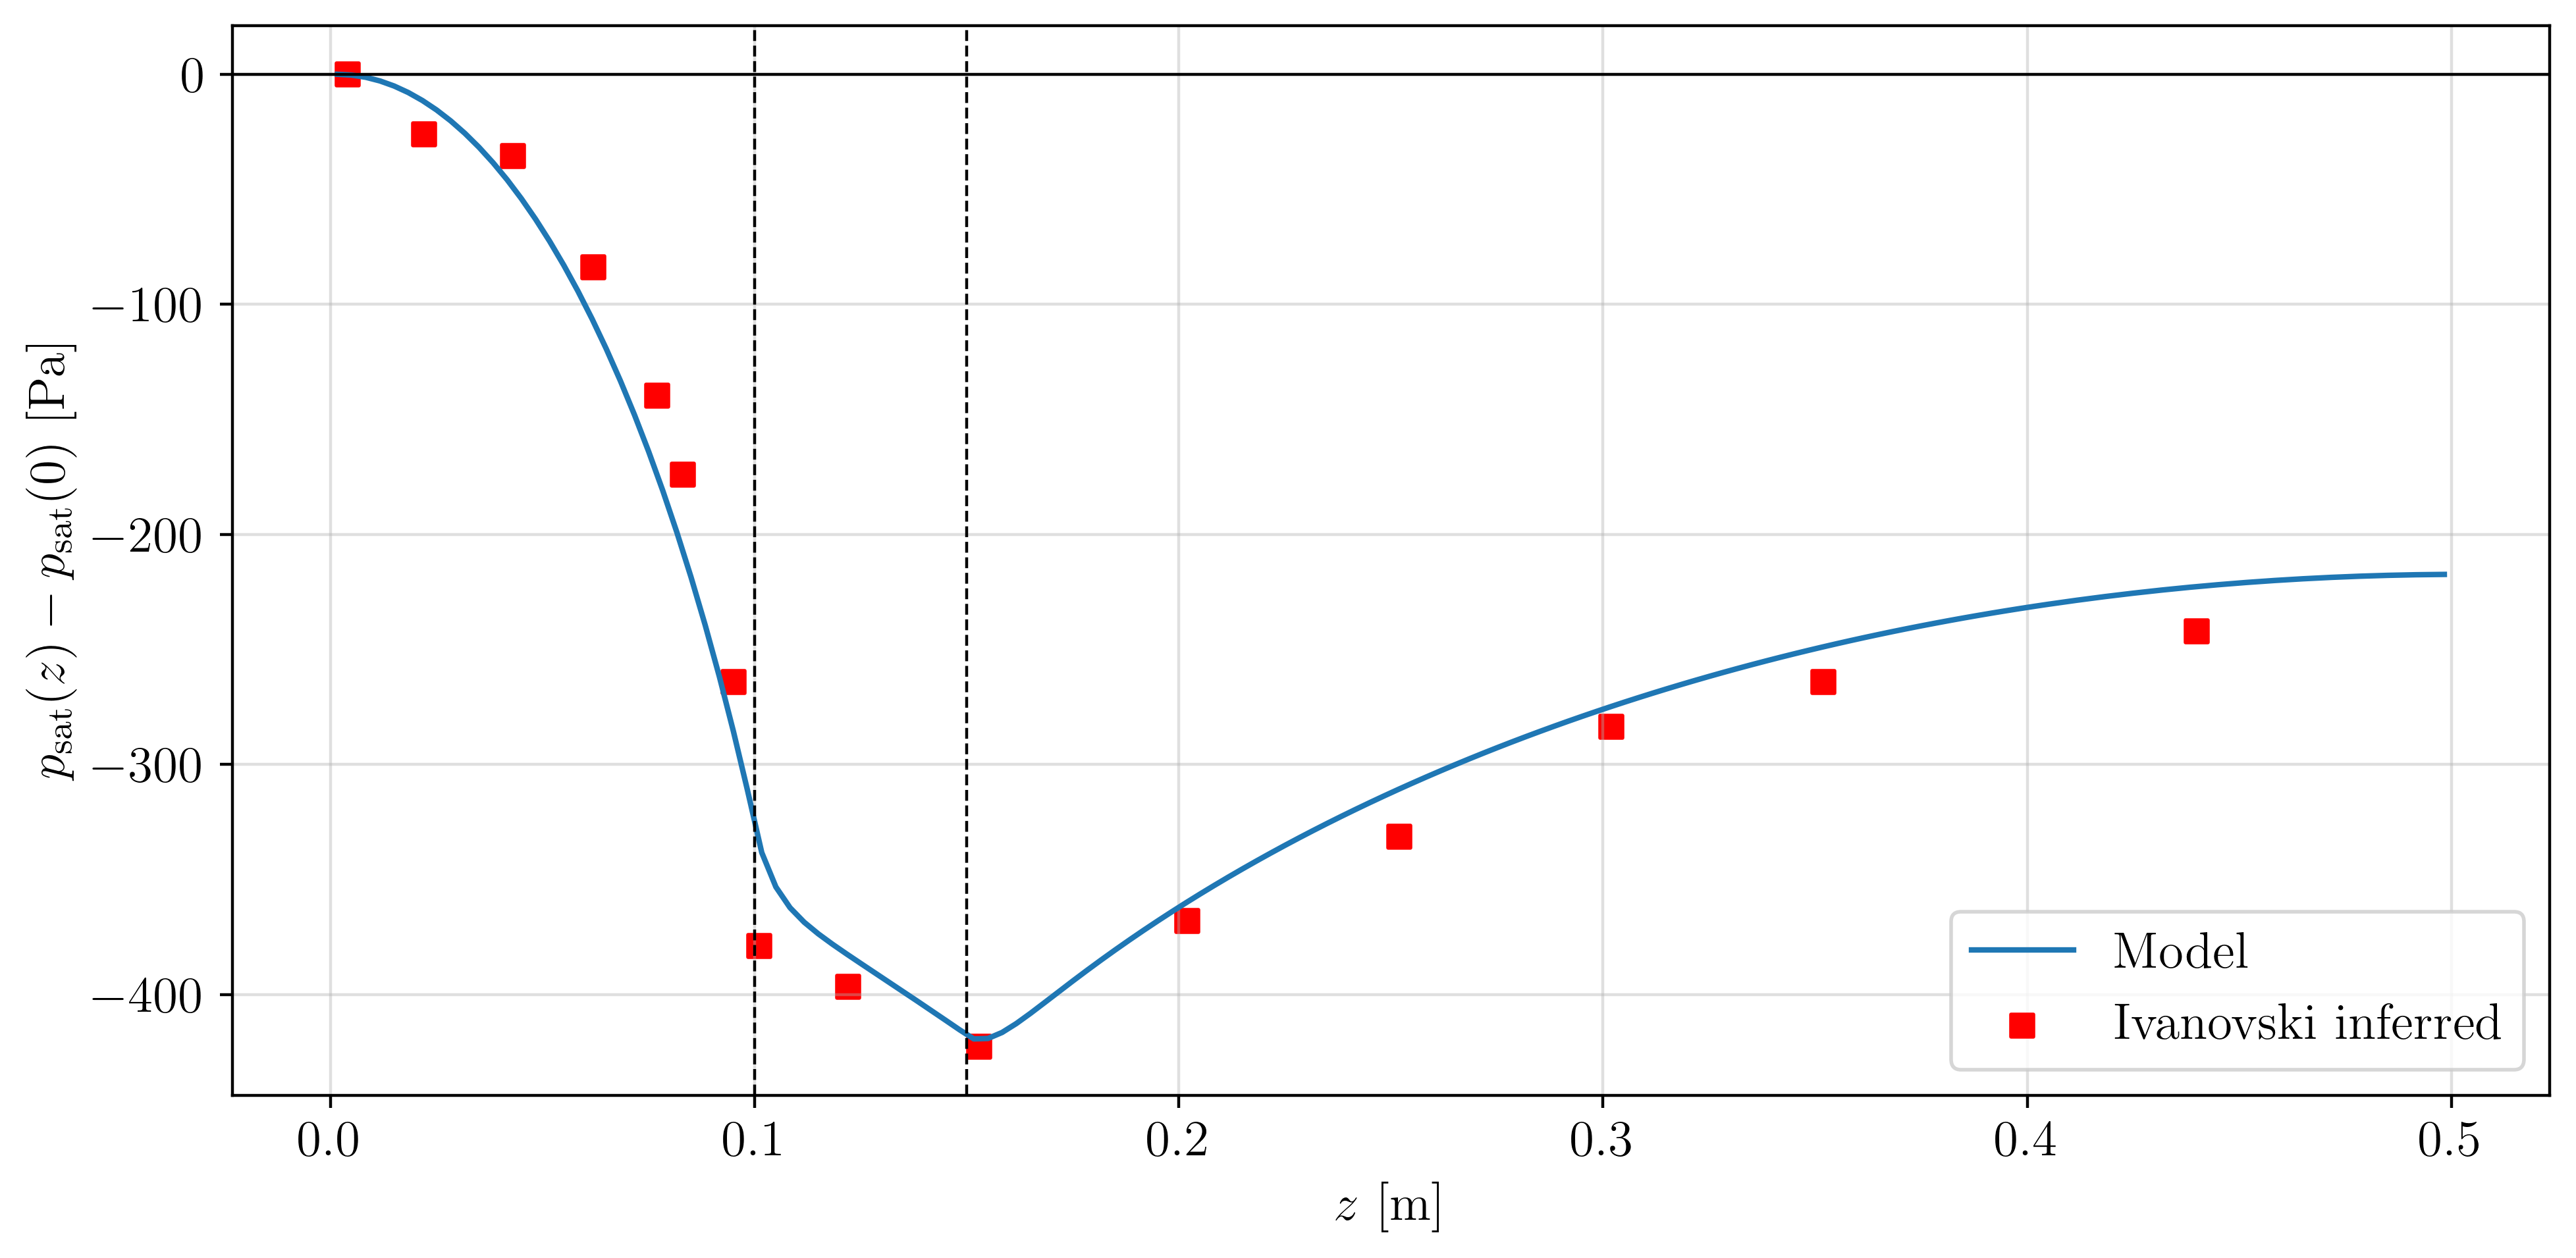

In [17]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)

ax.plot(Z, p_vap - p_vap[0], label="Model")
ax.scatter(z_ivanovski, p_exp - p_exp[0], label="Ivanovski inferred", marker="s", color="red")

ax.axhline(0, color="k", linewidth=0.8)
ax.axvline(heatpipe.cfg.geometry.l_evap, color="k", linestyle="--", linewidth=0.8)
ax.axvline(
    heatpipe.cfg.geometry.l_evap + heatpipe.cfg.geometry.l_adiabatic,
    color="k",
    linestyle="--",
    linewidth=0.8,
)

ax.set_xlabel(r"$z$ [m]")
ax.set_ylabel(r"$p_\mathrm{sat}(z) - p_\mathrm{sat}(0)$ [Pa]")
ax.grid(alpha=0.4)
ax.legend()

fig.tight_layout()
plt.show()

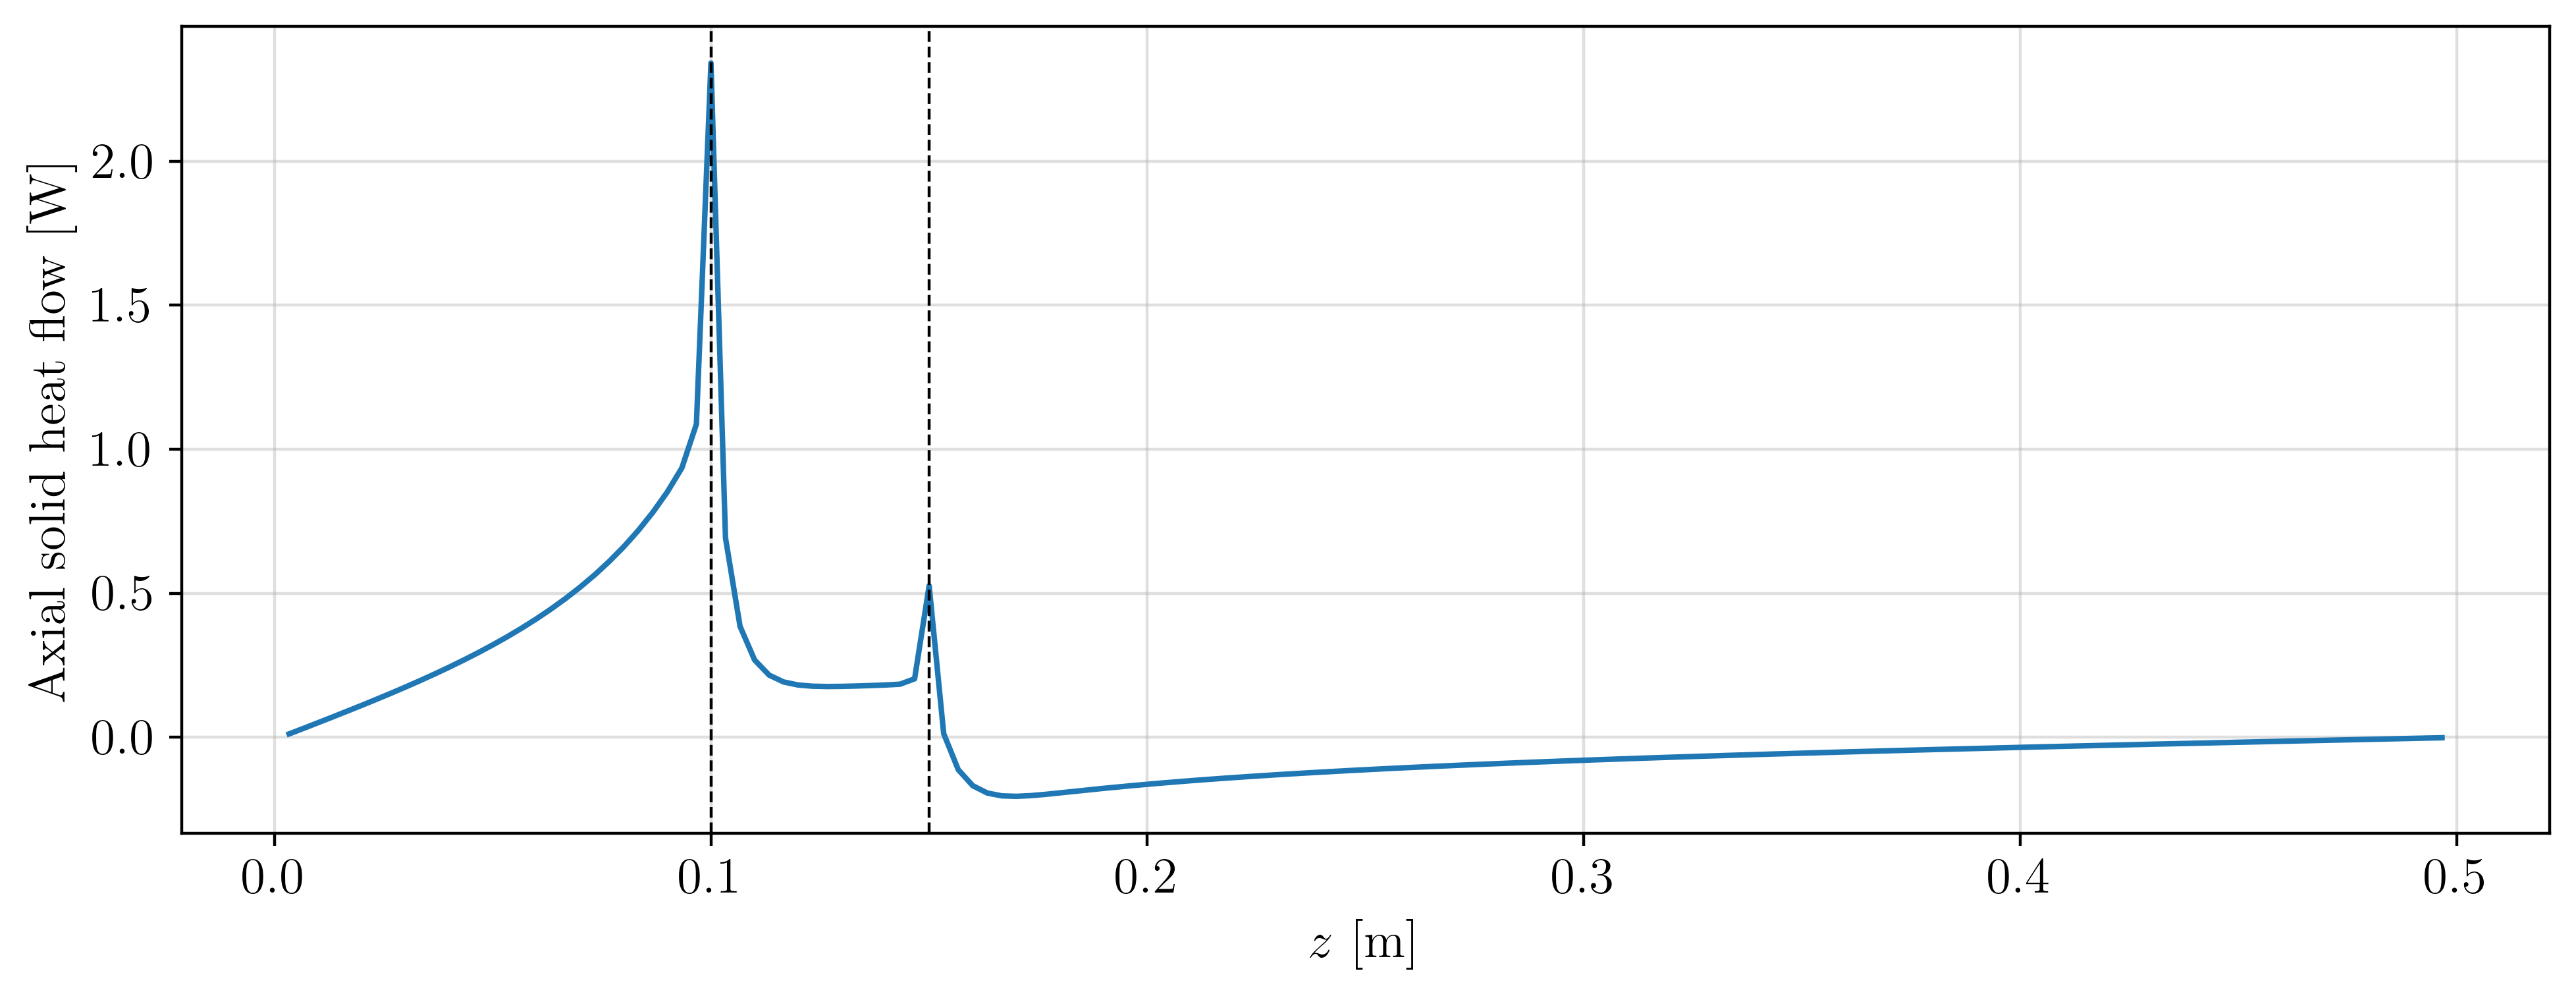

In [18]:
surface_areas, delta_Rp, delta_Rm, delta_Z = heatpipe.solid._initialize_discretization()
k = heatpipe.solid._generate_k_matrix(T_solid)
alpha = heatpipe.solid._generate_alpha(surface_areas, delta_Rm, delta_Rp, delta_Z, k)

# Conductive heat flow from z cell i to i+1, summed over radius
qz_faces = np.zeros(heatpipe.cfg.mesh.N_Z - 1)

for i in range(heatpipe.cfg.mesh.N_Z - 1):
    # Using the +z conductance from cell i
    qz_r = k[i, :] * alpha[i, :, 2] * (T_solid[i, :] - T_solid[i + 1, :])
    qz_faces[i] = np.sum(qz_r)

z_faces = 0.5 * (heatpipe.solid.Z[:-1] + heatpipe.solid.Z[1:])

fig, ax = plt.subplots(figsize=(10, 4), dpi=200)
ax.plot(z_faces, qz_faces)

ax.axvline(heatpipe.cfg.geometry.l_evap, color="k", linestyle="--", linewidth=0.8)
ax.axvline(
    heatpipe.cfg.geometry.l_evap + heatpipe.cfg.geometry.l_adiabatic,
    color="k",
    linestyle="--",
    linewidth=0.8,
)

ax.set_xlabel(r"$z$ [m]")
ax.set_ylabel(r"Axial solid heat flow [W]")
ax.grid(alpha=0.4)
fig.tight_layout()
plt.show()

In [19]:
p_model = s_props.calculate_Na_pressure_v(T_vap)
p_exp = s_props.calculate_Na_pressure_v(T_ivanovski)

print("T model max-min:", np.max(T_vap) - np.min(T_vap))
print("T exp max-min:", np.max(T_ivanovski) - np.min(T_ivanovski))

print("p model max-min:", np.max(p_model) - np.min(p_model))
print("p exp max-min:", np.max(p_exp) - np.min(p_exp))

print("pressure-drop ratio exp/model:",
      (np.max(p_exp) - np.min(p_exp)) / (np.max(p_model) - np.min(p_model)))

T model max-min: 20.53275743025233
T exp max-min: 20.700000000000045
p model max-min: 419.3329842611961
p exp max-min: 422.61808550698186
pressure-drop ratio exp/model: 1.0078341112411504


In [20]:
def vapour_momentum_terms(heatpipe, u, T_v):
    cfg = heatpipe.cfg

    Tbar = 0.5 * (T_v[1:] + T_v[:-1])

    rho = heatpipe.vapour.calculate_rho(T_v)
    rhobar = heatpipe.vapour.calculate_rho(Tbar)
    hfgbar = heatpipe.vapour.calculate_hfg(Tbar)

    u_full = np.zeros(cfg.mesh.N_Z + 1)
    u_full[1:-1] = u

    conv = np.zeros_like(u)

    for j in range(len(u)):
        i = j + 1

        u_im1 = u_full[i - 1]
        u_i = u_full[i]
        u_ip1 = u_full[i + 1]

        rho_im1 = rho[i - 1]
        rho_i = rho[i]

        u_avg_plus = 0.5 * (u_i + u_ip1)
        u_avg_minus = 0.5 * (u_im1 + u_i)

        u_plus = u_i if u_avg_plus >= 0.0 else u_ip1
        u_minus = u_im1 if u_avg_minus >= 0.0 else u_i

        conv[j] = (
            rho_i * u_avg_plus * u_plus
            - rho_im1 * u_avg_minus * u_minus
        )

    lam = heatpipe.vapour._calculate_friction_factor(T_v, u)
    Dh = 2.0 * cfg.geometry.r_vapour
    dx_face = 0.5 * (heatpipe.vapour.dx[:-1] + heatpipe.vapour.dx[1:])

    friction = dx_face * lam * rhobar * u * np.abs(u) / (2.0 * Dh)
    pressure = rhobar * hfgbar / Tbar * (T_v[1:] - T_v[:-1])

    return pressure, conv, friction

pressure, conv, friction = vapour_momentum_terms(heatpipe, u, T_vap)

print("sum pressure:", np.sum(pressure))
print("sum conv:", np.sum(conv))
print("sum friction:", np.sum(friction))

print("max |pressure|:", np.max(np.abs(pressure)))
print("max |conv|:", np.max(np.abs(conv)))
print("max |friction|:", np.max(np.abs(friction)))

sum pressure: -203.44809545580335
sum conv: 0.00934063836069754
sum friction: 203.42317967178224
max |pressure|: 25.389500456332446
max |conv|: 16.83781644856407
max |friction|: 2.724181839958142


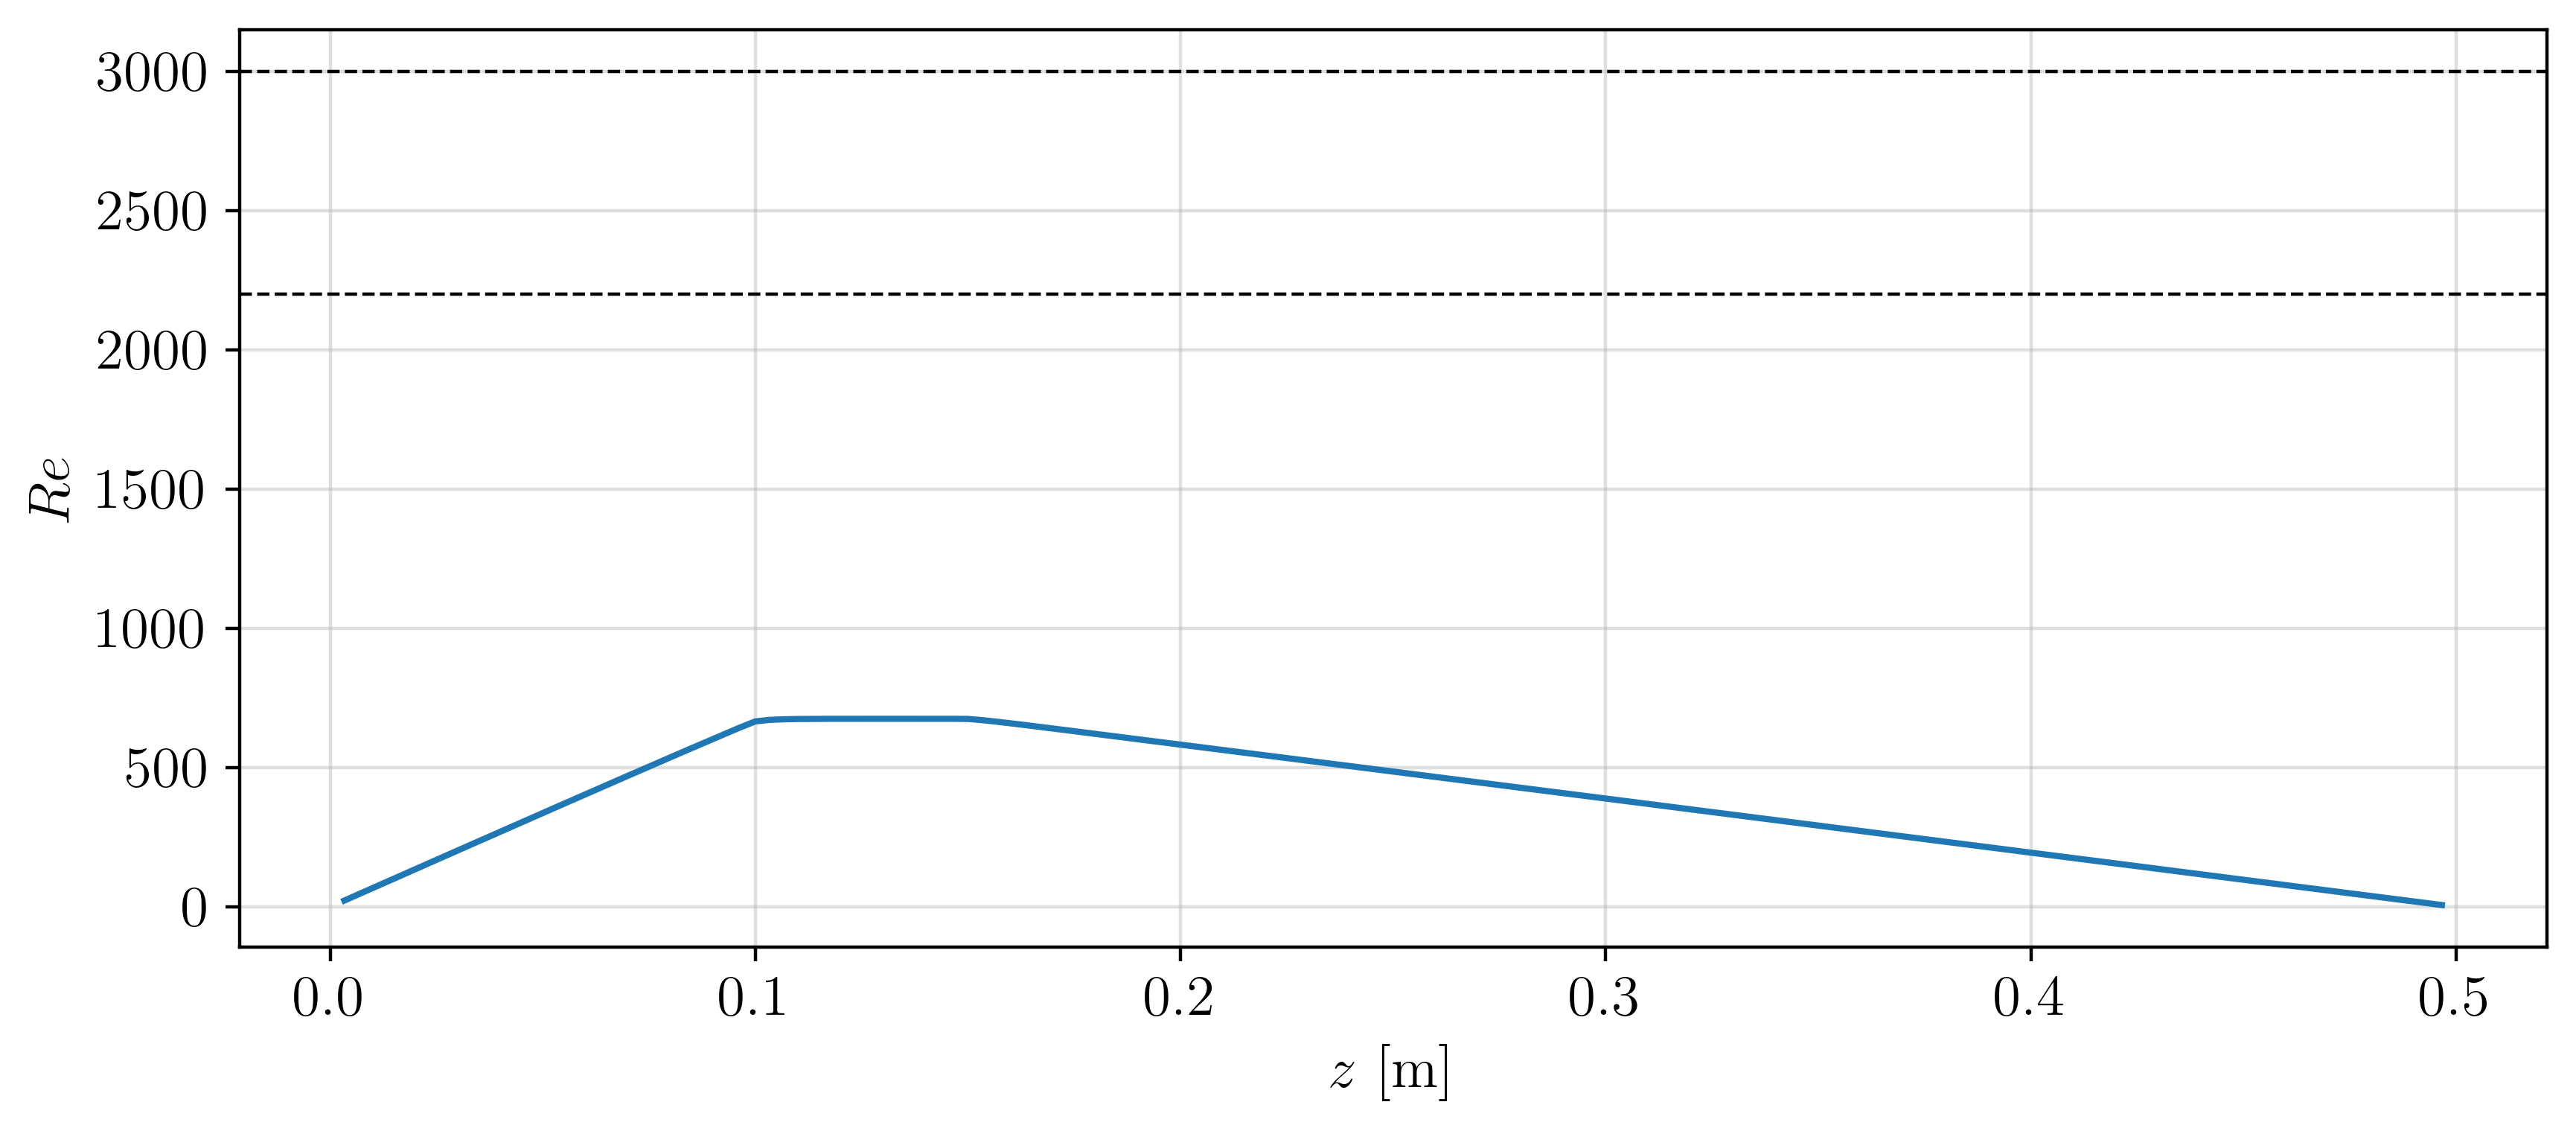

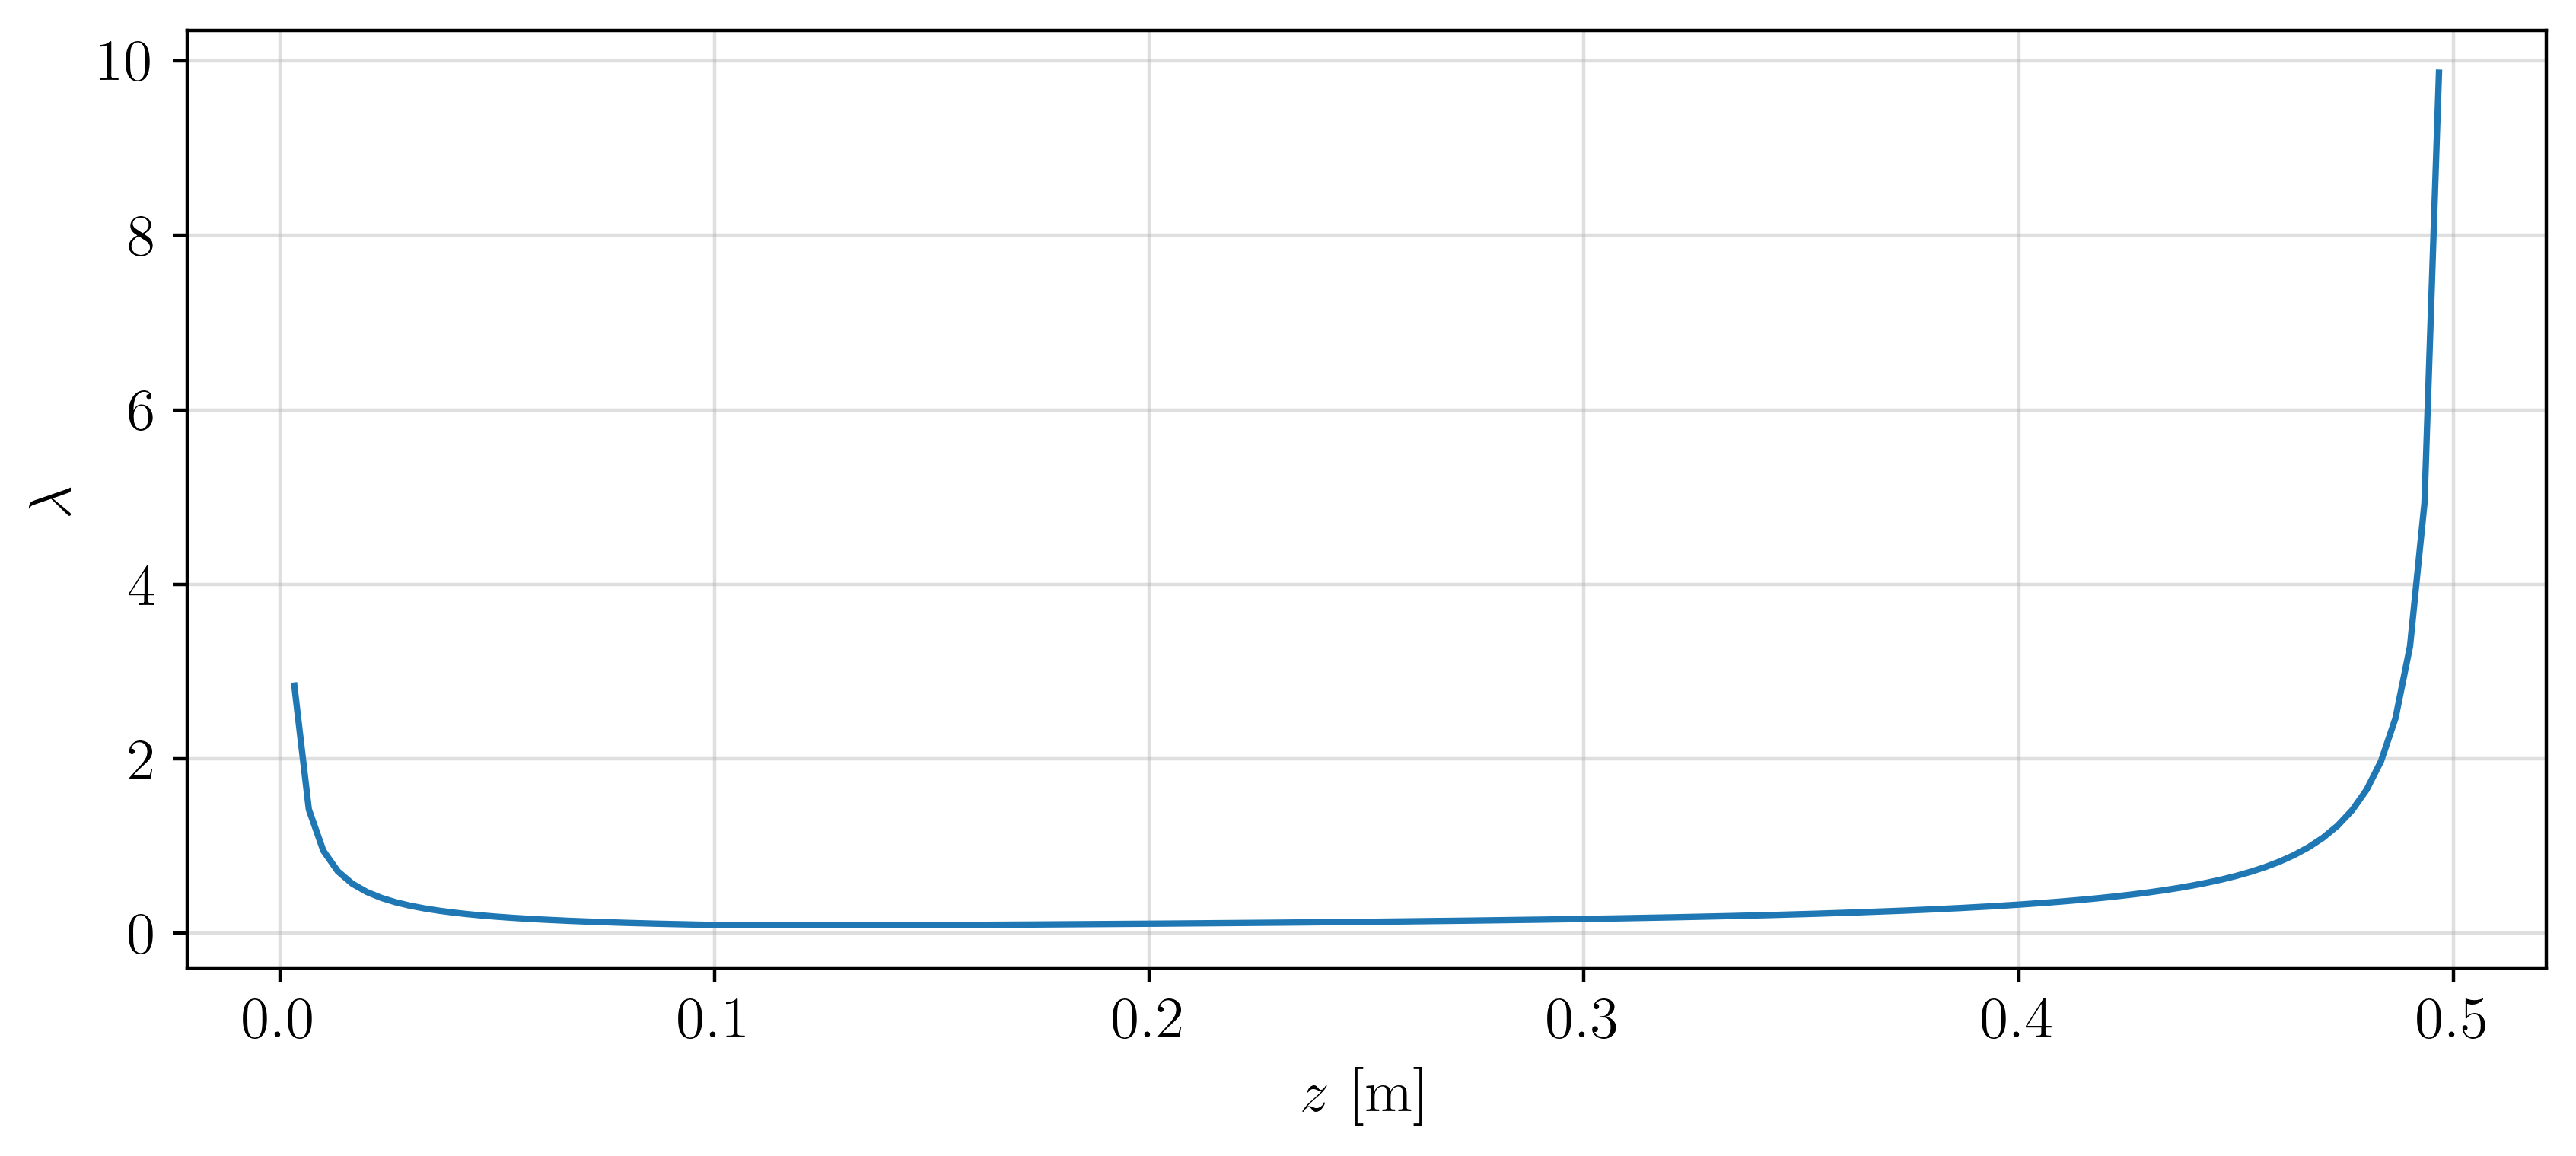

In [21]:
Re = heatpipe.vapour._calculate_reynolds(T_vap, u)
lam = heatpipe.vapour._calculate_friction_factor(T_vap, u)

z_face = 0.5 * (Z[:-1] + Z[1:])

fig, ax = plt.subplots(figsize=(10, 4), dpi=200)
ax.plot(z_face, Re)
ax.axhline(2200, color="k", linestyle="--", linewidth=0.8)
ax.axhline(3000, color="k", linestyle="--", linewidth=0.8)
ax.set_xlabel(r"$z$ [m]")
ax.set_ylabel(r"$Re$")
ax.grid(alpha=0.4)
plt.show()

fig, ax = plt.subplots(figsize=(10, 4), dpi=200)
ax.plot(z_face, lam)
ax.set_xlabel(r"$z$ [m]")
ax.set_ylabel(r"$\lambda$")
ax.grid(alpha=0.4)
plt.show()

In [22]:
p_model = s_props.calculate_Na_pressure_v(T_vap)
p_exp = s_props.calculate_Na_pressure_v(T_ivanovski)

print("T model max-min:", np.max(T_vap) - np.min(T_vap))
print("T exp max-min:", np.max(T_ivanovski) - np.min(T_ivanovski))

print("p model max-min:", np.max(p_model) - np.min(p_model))
print("p exp max-min:", np.max(p_exp) - np.min(p_exp))

print(
    "pressure-drop ratio exp/model:",
    (np.max(p_exp) - np.min(p_exp)) / (np.max(p_model) - np.min(p_model))
)

T model max-min: 20.53275743025233
T exp max-min: 20.700000000000045
p model max-min: 419.3329842611961
p exp max-min: 422.61808550698186
pressure-drop ratio exp/model: 1.0078341112411504


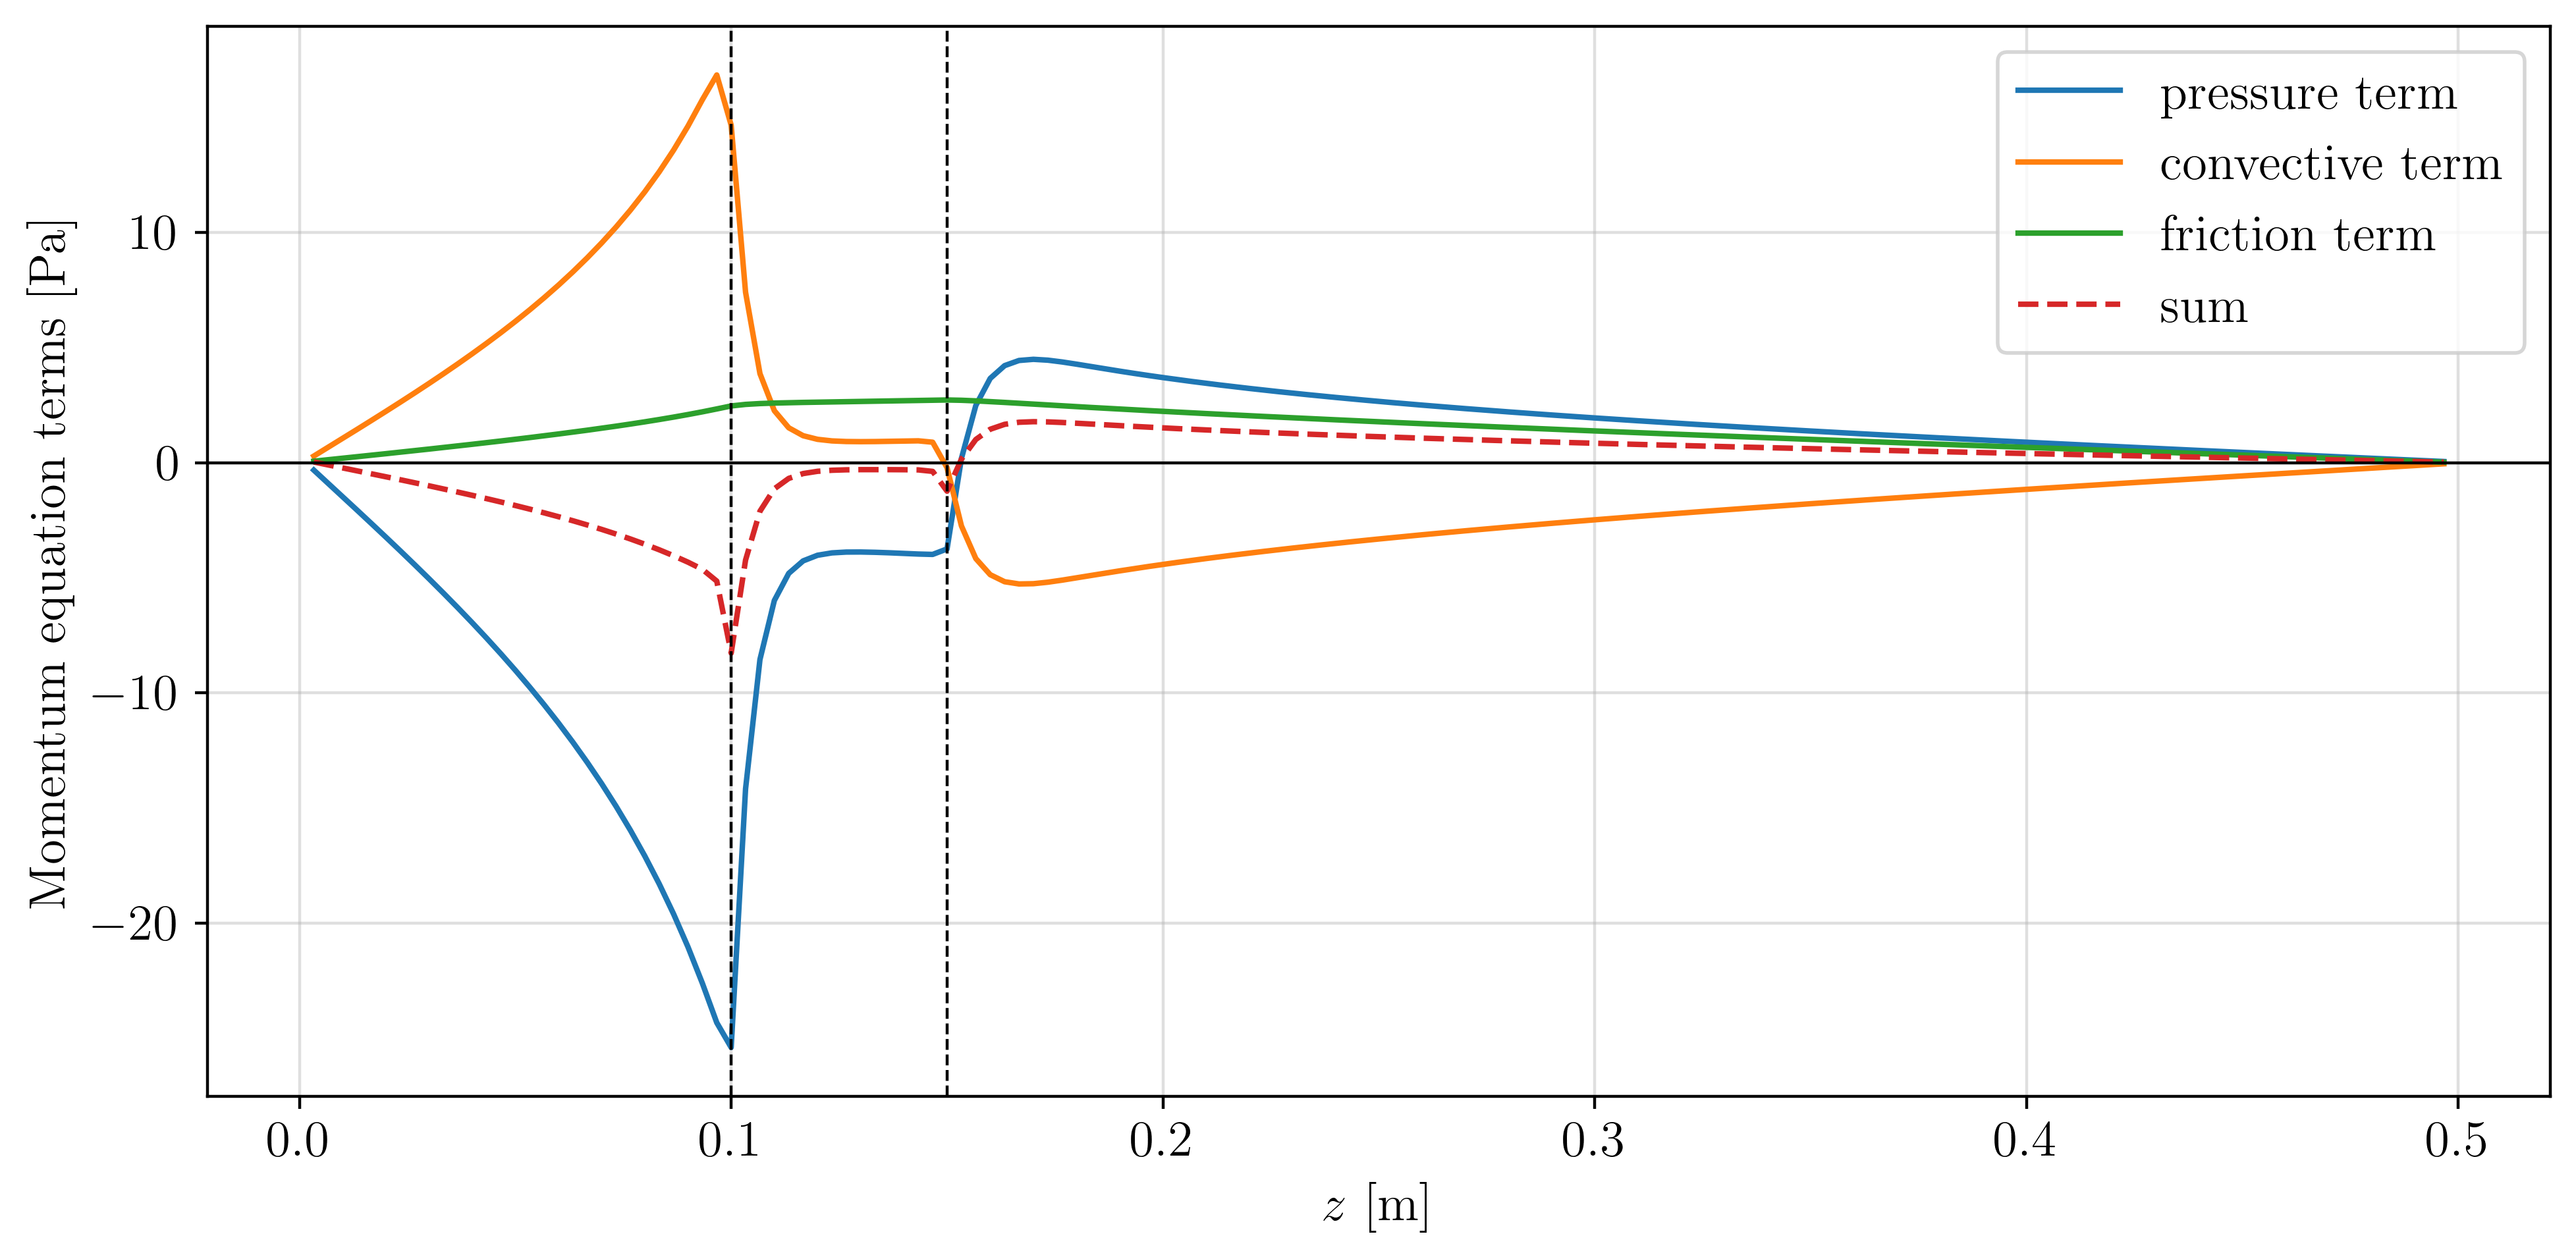

In [23]:
pressure, conv, friction = vapour_momentum_terms(heatpipe, u, T_vap)
z_face = 0.5 * (Z[:-1] + Z[1:])

fig, ax = plt.subplots(figsize=(10, 5), dpi=200)

ax.plot(z_face, pressure, label=r"pressure term")
ax.plot(z_face, conv, label=r"convective term")
ax.plot(z_face, friction, label=r"friction term")
ax.plot(z_face, pressure + conv + friction, "--", label="sum")

ax.axhline(0, color="k", linewidth=0.8)
ax.axvline(cfg.geometry.l_evap, color="k", linestyle="--", linewidth=0.8)
ax.axvline(cfg.geometry.l_evap + cfg.geometry.l_adiabatic, color="k", linestyle="--", linewidth=0.8)

ax.set_xlabel(r"$z$ [m]")
ax.set_ylabel(r"Momentum equation terms [Pa]")
ax.grid(alpha=0.4)
ax.legend()

fig.tight_layout()
plt.show()

In [24]:
T_face = 0.5 * (T_vap[:-1] + T_vap[1:])
mu_face = heatpipe.vapour.calculate_viscosity(T_face)
Dh = 2.0 * cfg.geometry.r_vapour

dpdx_poiseuille = 32.0 * mu_face * u / Dh**2

lam = heatpipe.vapour._calculate_friction_factor(T_vap, u)
rho_face = heatpipe.vapour.calculate_rho(T_face)
dpdx_darcy = lam * rho_face * u * np.abs(u) / (2.0 * Dh)

print("max relative difference:",
      np.max(np.abs(dpdx_darcy - dpdx_poiseuille) / np.maximum(np.abs(dpdx_poiseuille), 1e-30)))

max relative difference: 4.2968400249799105e-16


In [25]:
def mach_estimator(Q, T, p_c, T_c):
    R = 361.7
    gamma = 5 / 3
    h_fg = 4.182e6

    c_s = np.sqrt(gamma * R * T)
    rho = p_c / (R*T) * np.exp(h_fg / R * (1/T_c - 1/T))
    mdot = Q / h_fg
    A = np.pi*0.007**2
    u = mdot / (rho * A)

    print(u)

    mach = u / c_s
    return mach

print(mach_estimator(560, 798, 1300, 818))
print(mach_estimator(1000, 842, 2476, 856))

275.2420114861905
0.3968392755844518
239.17474553300846
0.3357071921609129
